<a href="https://colab.research.google.com/github/WoojinCho-Ryan/Studying-Pytorch/blob/main/6_Artificial_Neural_Network.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 6-1. Machine Learning 기본 개념 정리

## 1. Machine Learning Model 평가

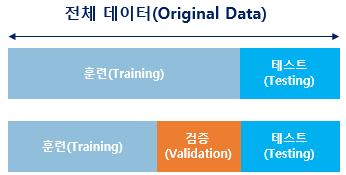

Validation data는 model의 성능을 평가하기 위한 용도가 아니고, model의 성능을 조정하기 위한 용도이다. 과적합이 되고 있는 판단하거나, hyperparamerer의 조정을 위한 용도가 된다. 여기서 **hyperparamer**는 값에 따라 model의 성능에 영향을 주는 매개변수들을 말함. weight과 bias처럼 학습을 통해 바뀌어져 가는 변수를 **매개변수**라고 함.

Traning data로 훈련을 모두 시킨 model은 Validation data를 통해 accuracy를 검증하고 hyperparamer를 tuning한다.

## 2. Classification, Regression

### 1) Binary Classification

### 2) Multi-class Classification

### 3) Regression

## 3. Supervised Learning and Unsupervised Learning

Machine learning은 크게 지도 학습, 비지도 학습, 강화 학습으로 나뉨. 여기서 강화 학습은 다루지 않음

## 4. Sample and Feature

## 5. Confusion Matrix (혼동 행렬)

맞춘 문제 수 / 전체 문제 수 = accuracy. 그러나 accuracy는 맞춘 결과와 틀린결과에 대한 세부적인 내용을 알려주지는 않음. 이를 위해 **Confusion Matrix**를 사용.

| (예측) \ (실제) | 참 (Positive) | 거짓 (Negative) |
| :---: | :---: | :---: |
| **참 (Positive)** | TP (True Positive) | FN (False Negative) |
| **거짓 (Negative)** | FP (False Positive) | TN (True Negative) |

### 1) Precision (정밀도)

positive라고 대답한 whole case에 대한 TP의 비율
$$ Precision = \frac{TP} {TP+FP} $$

### 2) Recall (재현률)

실제 값이 positive인 data의 전체 개수에 대한 TP의 비율
$$ Recall = \frac{TP}{TP+FN}$$

## 6. Overfitting and Underfitting

## 7. Nonlinear Activation Function

Nonlinear Activation Function: input을 받아 수학적 변환을 수행하고 output을 생성하는 function. Example: sigmoid, softmax.

일반적으로 인공 신경망의 은닉층에서는 Activation function으로 sigmoid가 지양되며, 주로 ReLU를 사용.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

### 1) Activate function의 특징 - Nonlinear

Linear function으로는 은닉층을 여러 번 추가하더라도 1번 추가한 것과 차이를 줄 수 없기 때문.

linear function을 사용한 층을 일반적으로 linear layer 또는 projection layer라고 부름.

### 2) Sigmoid function과 기울기 소실

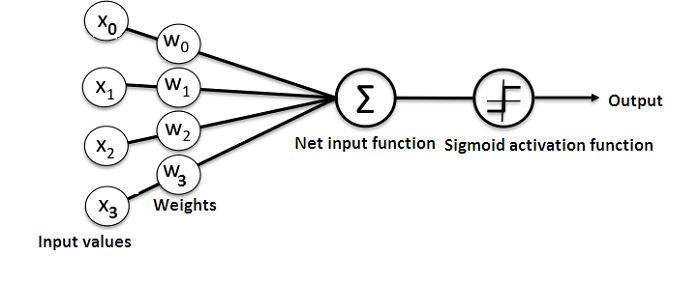

위 인공 신경망의 학습 과정은 다음과 같음.
- input에 대해 forward propagation(순전파) 연산
- forward propagation을 통해 나온 예측값과 실제값의 error를 loss function을 통해 계산
- loss를 derivative를 통해 gradient를 구하고, 이를 통해 back propagation(역전파) 수행

Sigmoid function의 문제는 gradient를 구할 때 발생

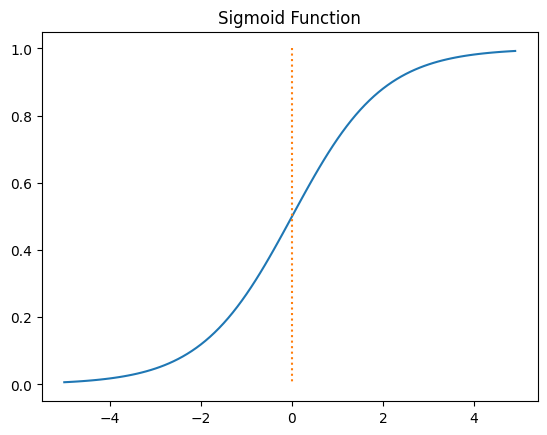

In [3]:
def sigmoid(x):
  return 1 / (1 + np.exp(-x))

x = np.arange(-5.0, 5.0, 0.1)
y = sigmoid(x)

plt.plot(x, y)
plt.plot([0,0],[1.0, 0.0], ':')
plt.title('Sigmoid Function')
plt.show()

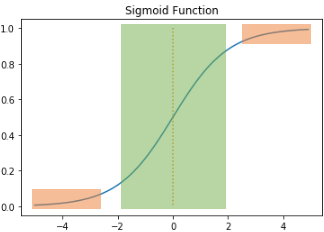

back propagation 과정에서 0에 가까운 아주 작은 기울기가 곱해지면, 앞단에는 그 기울기가 잘 전달되지 않게 됨. 이러한 현상을 **Vanishing Gradient**라고 함.즉 sigmoid를 사용하는 은닉층의 개수가 다수가 될 경우에는 거의 기울기를 전파받을 수 없음. 즉, weight $W$가 update되지 못함.

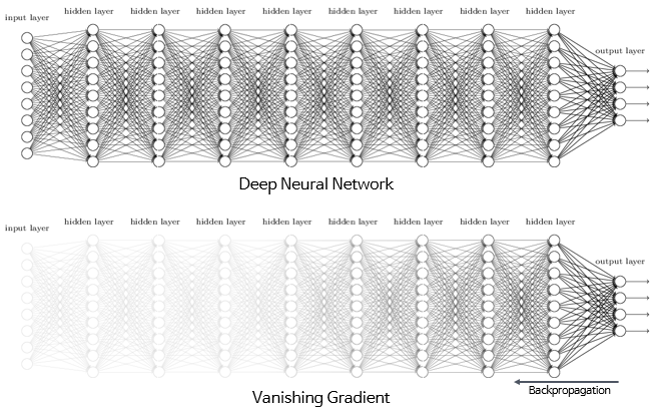

### 3) Hyperbolic tangent function

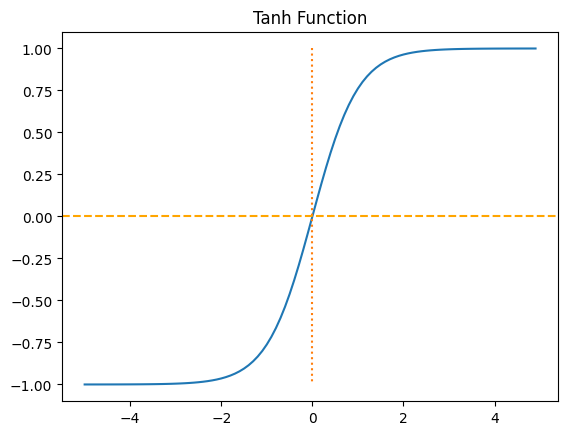

In [4]:
x = np.arange(-5.0, 5.0, 0.1) # -5.0부터 5.0까지 0.1 간격 생성
y = np.tanh(x)

plt.plot(x, y)
plt.plot([0,0],[1.0,-1.0], ':')
plt.axhline(y=0, color='orange', linestyle='--')
plt.title('Tanh Function')
plt.show()

### 4) ReLU

$$ f(x) = max(0, x) $$

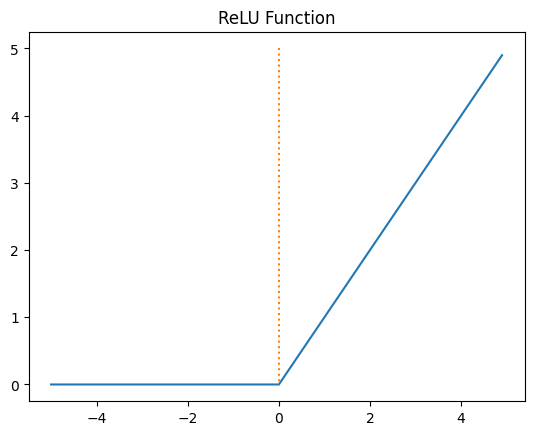

In [5]:
def relu(x):
  return np.maximum(0, x)

x = np.arange(-5.0, 5.0, 0.1)
y = relu(x)

plt.plot(x, y)
plt.plot([0, 0], [5.0, 0.0], ':')
plt.title('ReLU Function')
plt.show()

문제점: 입력값이 음수면 기울기도 0이 됨. 이 뉴런은 다시 회생하는 것이 매우 어려움. 이러한 문제를 dying ReLU라고 함.

### 5) Leaky ReLU

$$ f(x) = max(ax, x) $$
a는 hyperparameter로 Leaky한 정도를 결정하며 일반적으로는 0.01의 값을 가짐.

In [6]:
a = 0.1

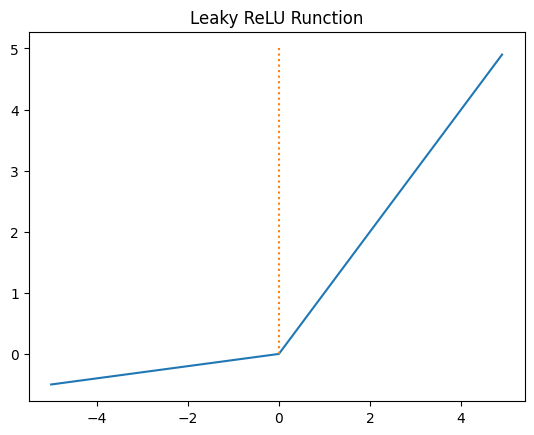

In [7]:
def leaky_relu(x):
  return np.maximum(a * x, x)

x = np.arange(-5.0, 5.0, 0.1)
y = leaky_relu(x)

plt.plot(x, y)
plt.plot([0,0],[5.0,0.0],':')
plt.title('Leaky ReLU Runction')
plt.show()

### 6) Softmax Function

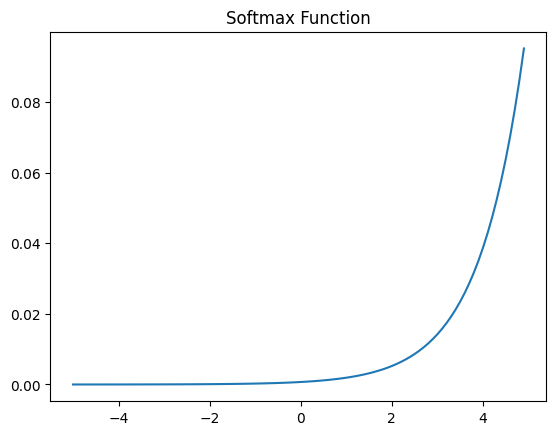

In [8]:
x = np.arange(-5.0, 5.0, 0.1) # -5.0부터 5.0까지 0.1 간격 생성
y = np.exp(x) / np.sum(np.exp(x))

plt.plot(x, y)
plt.title('Softmax Function')
plt.show()

### 7) 출력층의 활성화 함수와 오차 함수의 관계

은닉층에서는 ReLU 또는 Leaky ReLU와 같은 ReLU의 변형을 주로 사용. 출력층은 다음과 같음.
- 이진 분류: sigmoid, nn.BCELoss()
- 다중 class 분류: softmax, nn.CrossEntropyLoss() [이미 crossentropy 내에 softmax 포함되어 있음]
- Regression: activate function 없음, MSE

Stanford의 Deep Learning 강의 CS231N에서는 ReLU를 먼저 시도해보고, 그다음으로 LeakyReLU나 ELU 같은 ReLU의 변형들을 시도해보며, sigmoid는 사용하지 말라고 권장합니다.

# 6-2. Perceptron

## 1. Perceptron

Perceptron: 다수의 input으로부터 하나의 result를 내보내는 algorithm.

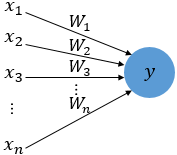

$x$: input, $W$: weight, $y$: output.

각 input이 weight과 곱해져서 artificial neuron에 보내지고, 각 input과 그에 해당되는 weight의 곱의 sum이 threshold(임계치)를 넘으면 종착지에 있는 artificial neuron은 1을 출력, 그 외는 0 출력. 이러한 function을 **Step Function**이라 함. 아래의 그래프는 step function의 예시 중 하나.

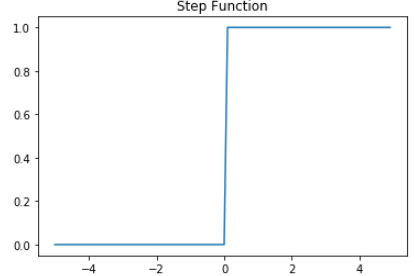

step function에서 사용된 threshold를 수식으로 표현할 때는 보통 theta ($\theta$)로 표현.

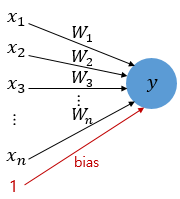

$$ \text{if} \ \sum_{i}^{n}W_ix_i+b \ge 0 \rightarrow y = 1 $$

$$ \text{if} \ \sum_{i}^{n}W_ix_i+b < 0 \rightarrow y = 0 $$

- artificial neuron: activation function $f(\sum_{i}^{n}W_ix_i+b )$
- perceptron: step function $f(\sum_{i}^{n}W_ix_i+b )$

## 2. Single-Layer Perceptron

위에서 다룬 perceptron을 **Single-Layer Perceptron**라고 함. Single-Layer Perceptron은 값을 보내는 단계와 값을 받아서 출력하는 두 단계로만 이루어짐. 각 단계를 layer라고 부르며, 각각 input layer와 output layer가 된다.

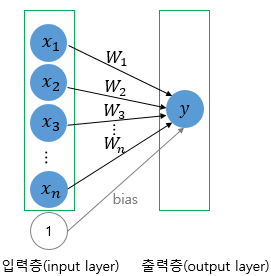

Single-Layer Perceptron을 통해 AND, NAND, OR gate를 쉽게 구현 가능.

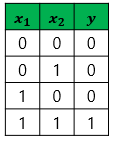

In [9]:
def AND_gate(x1, x2):
    w1=0.5
    w2=0.5
    b=-0.7
    result = x1*w1 + x2*w2 + b
    if result <= 0:
        return 0
    else:
        return 1

In [10]:
AND_gate(0, 0), AND_gate(0, 1), AND_gate(1, 0), AND_gate(1, 1)

(0, 0, 0, 1)

In [11]:
def NAND_gate(x1, x2):
    w1=-0.5
    w2=-0.5
    b=0.7
    result = x1*w1 + x2*w2 + b
    if result <= 0:
        return 0
    else:
        return 1

In [12]:
NAND_gate(0, 0), NAND_gate(0, 1), NAND_gate(1, 0), NAND_gate(1, 1)

(1, 1, 1, 0)

In [13]:
def OR_gate(x1, x2):
    w1=0.6
    w2=0.6
    b=-0.5
    result = x1*w1 + x2*w2 + b
    if result <= 0:
        return 0
    else:
        return 1

In [14]:
OR_gate(0, 0), OR_gate(0, 1), OR_gate(1, 0), OR_gate(1, 1)

(0, 1, 1, 1)

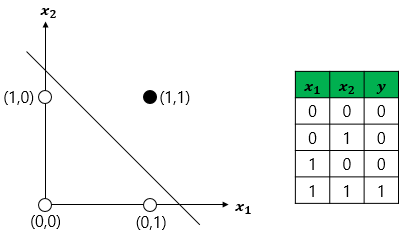

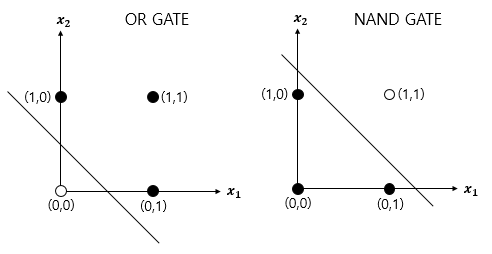

SIngle-Layer Perceptron으로 XOR gate는 표현 불가능. 하나의 직선으로 하얀색 원과 검은색 원을 나눌 수 없기 때문.

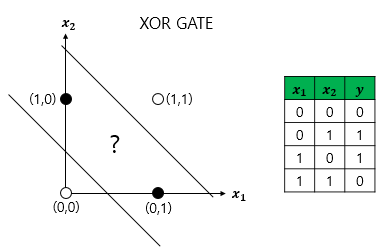

즉 XOR gate를 구현하기 위해서는 nonlinear area가 필요.

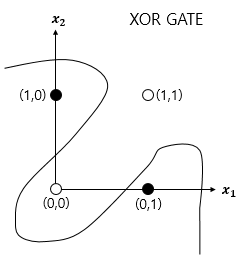

## 3. MultiLayer Perceptron, MLP

input layer와 output layer 사이에 존재하는 층: **hidden layer**

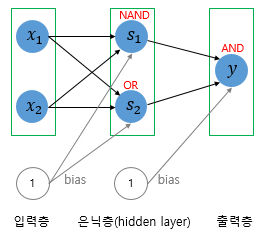

위와 같이 XOR gate를 구현할 수 있음.

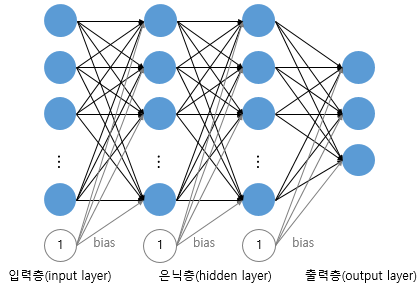

위와 같이 hidden layer가 2개 이상인 network를 **Deep Neural Network (DNN)**라고 함. 이는 MultiLayer Perceptron뿐만이 아니고, 여러 변형된 다양한 network도 hidden layer가 2개 이상이면 DNN이라 함.

지금까지는 weight를 수동으로 찾았지만, 이제는 machine이 스스로 weight를 찾아내도록 자동화할 것이며, 이것이 training step에 해당된다. 이 역시 loss function과 optimizer를 사용하며, 학습시키는 인공신경망이 DNN인 경우 이를 DNN을 학습시킨다고 하며 **Deep Learning**이라 부른다.

# 6-3. XOR 문제 구현하기 - Single Layer Perceptron and MultiLayer Perceptron

## 1. PyTorch로 Single Layer Perceptron 구현하기

In [1]:
import torch
import torch.nn as nn

In [2]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
torch.manual_seed(777)
if device == 'cuda':
  torch.cuda.manual_seed_all(777)

### 1) Single Layer Perceptron을 이용한 XOR 문제 풀기

In [3]:
X = torch.FloatTensor([[0, 0], [0, 1], [1, 0], [1, 1]]).to(device)
Y = torch.FloatTensor([[0], [1], [1], [0]]).to(device)

In [4]:
linear = nn.Linear(2, 1, bias = True)
sigmoid = nn.Sigmoid()
model = nn.Sequential(linear, sigmoid).to(device)

In [5]:
# define cost function, optimizer
criterion = torch.nn.BCELoss().to(device)
optimizer = torch.optim.SGD(model.parameters(), lr = 1)

In [6]:
for step in range(10001):
    optimizer.zero_grad()
    hypothesis = model(X)

    # 비용 함수
    cost = criterion(hypothesis, Y)
    cost.backward()
    optimizer.step()

    if step % 100 == 0: # 100번째 에포크마다 비용 출력
        print(step, cost.item())

0 0.7273973822593689
100 0.6931475400924683
200 0.6931471824645996
300 0.6931471824645996
400 0.6931471824645996
500 0.6931471824645996
600 0.6931471824645996
700 0.6931471824645996
800 0.6931471824645996
900 0.6931471824645996
1000 0.6931471824645996
1100 0.6931471824645996
1200 0.6931471824645996
1300 0.6931471824645996
1400 0.6931471824645996
1500 0.6931471824645996
1600 0.6931471824645996
1700 0.6931471824645996
1800 0.6931471824645996
1900 0.6931471824645996
2000 0.6931471824645996
2100 0.6931471824645996
2200 0.6931471824645996
2300 0.6931471824645996
2400 0.6931471824645996
2500 0.6931471824645996
2600 0.6931471824645996
2700 0.6931471824645996
2800 0.6931471824645996
2900 0.6931471824645996
3000 0.6931471824645996
3100 0.6931471824645996
3200 0.6931471824645996
3300 0.6931471824645996
3400 0.6931471824645996
3500 0.6931471824645996
3600 0.6931471824645996
3700 0.6931471824645996
3800 0.6931471824645996
3900 0.6931471824645996
4000 0.6931471824645996
4100 0.6931471824645996
4200

cost가 일정 이하로 줄어들지 않는 것은, 단층 perceptron을 통해 XOR problem을 풀 수 없기 때문.

### 2) 학습된 Single Layer Perceptron의 예측값 확인하기

In [7]:
with torch.no_grad():
    hypothesis = model(X)
    predicted = (hypothesis > 0.5).float()
    accuracy = (predicted == Y).float().mean()
    print('모델의 출력값(Hypothesis): ', hypothesis.detach().cpu().numpy())
    print('모델의 예측값(Predicted): ', predicted.detach().cpu().numpy())
    print('실제값(Y): ', Y.cpu().numpy())
    print('정확도(Accuracy): ', accuracy.item())

모델의 출력값(Hypothesis):  [[0.5]
 [0.5]
 [0.5]
 [0.5]]
모델의 예측값(Predicted):  [[0.]
 [0.]
 [0.]
 [0.]]
실제값(Y):  [[0.]
 [1.]
 [1.]
 [0.]]
정확도(Accuracy):  0.5


## 2. PyTorch로 MultiLayer Perceptron 구현하기

In [9]:
import torch
import torch.nn as nn

In [10]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# for reproducibility
torch.manual_seed(777)
if device == 'cuda':
    torch.cuda.manual_seed_all(777)

### 1) MultiLayer Perceptron을 이용한 XOR 문제 풀기

In [11]:
X = torch.FloatTensor([[0, 0], [0, 1], [1, 0], [1, 1]]).to(device)
Y = torch.FloatTensor([[0], [1], [1], [0]]).to(device)

In [12]:
model = nn.Sequential(
          nn.Linear(2, 10, bias=True), # input_layer = 2, hidden_layer1 = 10
          nn.Sigmoid(),
          nn.Linear(10, 10, bias=True), # hidden_layer1 = 10, hidden_layer2 = 10
          nn.Sigmoid(),
          nn.Linear(10, 10, bias=True), # hidden_layer2 = 10, hidden_layer3 = 10
          nn.Sigmoid(),
          nn.Linear(10, 1, bias=True), # hidden_layer3 = 10, output_layer = 1
          nn.Sigmoid()
          ).to(device)

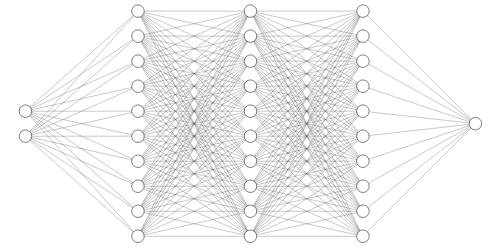

In [13]:
criterion = torch.nn.BCELoss().to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=1)  # modified learning rate from 0.1 to 1

각 epoch마다 back propagation이 수행됨.

In [14]:
for epoch in range(10001):
    optimizer.zero_grad()
    # forward 연산
    hypothesis = model(X)

    # 비용 함수
    cost = criterion(hypothesis, Y)
    cost.backward()
    optimizer.step()

    # 100의 배수에 해당되는 에포크마다 비용을 출력
    if epoch % 100 == 0:
        print(epoch, cost.item())

0 0.6948983669281006
100 0.693155825138092
200 0.6931535005569458
300 0.6931513547897339
400 0.6931492686271667
500 0.6931473016738892
600 0.6931453943252563
700 0.6931434869766235
800 0.6931416392326355
900 0.6931397914886475
1000 0.6931380033493042
1100 0.6931362152099609
1200 0.6931343078613281
1300 0.6931324005126953
1400 0.6931304931640625
1500 0.6931284666061401
1600 0.6931264400482178
1700 0.6931242942810059
1800 0.6931220293045044
1900 0.6931196451187134
2000 0.6931171417236328
2100 0.6931145191192627
2200 0.6931116580963135
2300 0.6931085586547852
2400 0.6931051015853882
2500 0.6931014657020569
2600 0.6930974721908569
2700 0.6930930018424988
2800 0.6930880546569824
2900 0.6930825114250183
3000 0.6930763125419617
3100 0.6930692791938782
3200 0.6930612325668335
3300 0.6930519342422485
3400 0.6930411458015442
3500 0.693028450012207
3600 0.6930133104324341
3700 0.6929951906204224
3800 0.6929729580879211
3900 0.6929453015327454
4000 0.6929103136062622
4100 0.6928649544715881
4200 0

### 2) 학습된 MultiLayer Perceptron의 예측값 확인하기

In [15]:
with torch.no_grad():
    hypothesis = model(X)
    predicted = (hypothesis > 0.5).float()
    accuracy = (predicted == Y).float().mean()
    print('모델의 출력값(Hypothesis): ', hypothesis.detach().cpu().numpy())
    print('모델의 예측값(Predicted): ', predicted.detach().cpu().numpy())
    print('실제값(Y): ', Y.cpu().numpy())
    print('정확도(Accuracy): ', accuracy.item())

모델의 출력값(Hypothesis):  [[1.1169227e-04]
 [9.9982882e-01]
 [9.9984241e-01]
 [1.8534942e-04]]
모델의 예측값(Predicted):  [[0.]
 [1.]
 [1.]
 [0.]]
실제값(Y):  [[0.]
 [1.]
 [1.]
 [0.]]
정확도(Accuracy):  1.0


# 6-4. Back Propagation

## 1. Neural Network Overview

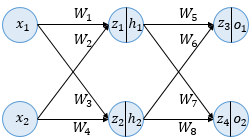

해당 Neural Network에서 bias $b$는 고려하지 않음.

## 2. Forward Propagation

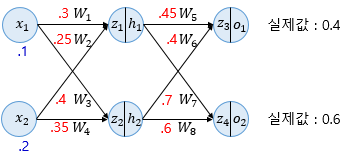

## 3. Back Propagation Step 1


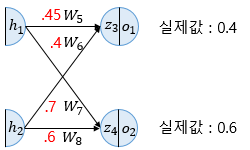

## 4. Back Propagation Step 2

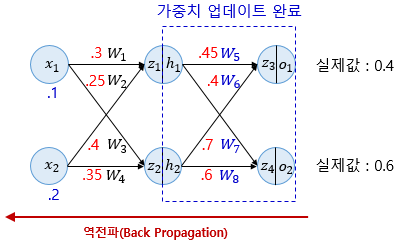

## 5. 결과 확인

# 6-5. MultiLayer Perceptron으로 손글씨 분류하기

## 1. 숫자 필기 데이터 소개

In [16]:
import matplotlib.pyplot as plt # 시각화를 위한 맷플롯립
from sklearn.datasets import load_digits
digits = load_digits() # 1,979개의 이미지 데이터 로드

In [17]:
print(digits.images[0])

[[ 0.  0.  5. 13.  9.  1.  0.  0.]
 [ 0.  0. 13. 15. 10. 15.  5.  0.]
 [ 0.  3. 15.  2.  0. 11.  8.  0.]
 [ 0.  4. 12.  0.  0.  8.  8.  0.]
 [ 0.  5.  8.  0.  0.  9.  8.  0.]
 [ 0.  4. 11.  0.  1. 12.  7.  0.]
 [ 0.  2. 14.  5. 10. 12.  0.  0.]
 [ 0.  0.  6. 13. 10.  0.  0.  0.]]


In [18]:
print(digits.target[0])

0


In [19]:
print('전체 샘플의 수 : {}'.format(len(digits.images)))

전체 샘플의 수 : 1797


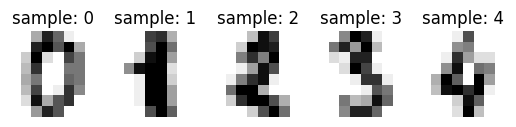

In [20]:
images_and_labels = list(zip(digits.images, digits.target))
for index, (image, label) in enumerate(images_and_labels[:5]): # 5개의 샘플만 출력
    plt.subplot(2, 5, index + 1)
    plt.axis('off')
    plt.imshow(image, cmap=plt.cm.gray_r, interpolation='nearest')
    plt.title('sample: %i' % label)

In [21]:
for i in range(5):
  print(i,'번 인덱스 샘플의 레이블 : ',digits.target[i])

0 번 인덱스 샘플의 레이블 :  0
1 번 인덱스 샘플의 레이블 :  1
2 번 인덱스 샘플의 레이블 :  2
3 번 인덱스 샘플의 레이블 :  3
4 번 인덱스 샘플의 레이블 :  4


In [22]:
print(digits.data[0])

[ 0.  0.  5. 13.  9.  1.  0.  0.  0.  0. 13. 15. 10. 15.  5.  0.  0.  3.
 15.  2.  0. 11.  8.  0.  0.  4. 12.  0.  0.  8.  8.  0.  0.  5.  8.  0.
  0.  9.  8.  0.  0.  4. 11.  0.  1. 12.  7.  0.  0.  2. 14.  5. 10. 12.
  0.  0.  0.  0.  6. 13. 10.  0.  0.  0.]


In [23]:
X = digits.data # 이미지. 즉, 특성 행렬
Y = digits.target # 각 이미지에 대한 레이블

## 2. MultiLayer Perceptron 분류기 만들기

In [25]:
import torch
import torch.nn as nn
from torch import optim

- First layer (nn.Linear(64, 32)): input layer. input data의 feature 수가 64개.
- First activate function (nn.ReLU())
- Second layer (nn.Linear(32, 16))
- Second activate function (nn.ReLU())
- Third layer (nn.Linear(16, 10)): 여기서 10은 class의 개수.

In [26]:
model = nn.Sequential(
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Linear(32, 16),
    nn.ReLU(),
    nn.Linear(16, 10)
)

In [27]:
X = torch.tensor(X, dtype = torch.float32)
Y = torch.tensor(Y, dtype = torch.int64)

In [28]:
loss_fn = nn.CrossEntropyLoss()

In [29]:
optimizer = optim.Adam(model.parameters()) # Adam

In [30]:
losses = []

In [31]:
# 총 100번의 에포크 동안 모델 학습
for epoch in range(100):
  optimizer.zero_grad()      # 옵티마이저의 기울기 초기화
  y_pred = model(X)          # 순전파 연산으로 예측값 계산
  loss = loss_fn(y_pred, Y)  # 손실 함수로 비용 계산
  loss.backward()            # 역전파 연산으로 기울기 계산
  optimizer.step()           # 옵티마이저를 통해 파라미터 업데이트

  # 10번째 에포크마다 현재 에포크와 손실 값 출력
  if epoch % 10 == 0:
    print('Epoch {:4d}/{} Cost: {:.6f}'.format(
            epoch, 100, loss.item()
        ))

  # 손실 값을 리스트에 추가하여 추적
  losses.append(loss.item())

Epoch    0/100 Cost: 2.381846
Epoch   10/100 Cost: 2.086940
Epoch   20/100 Cost: 1.844468
Epoch   30/100 Cost: 1.555474
Epoch   40/100 Cost: 1.246410
Epoch   50/100 Cost: 0.968091
Epoch   60/100 Cost: 0.724376
Epoch   70/100 Cost: 0.519714
Epoch   80/100 Cost: 0.380597
Epoch   90/100 Cost: 0.293385


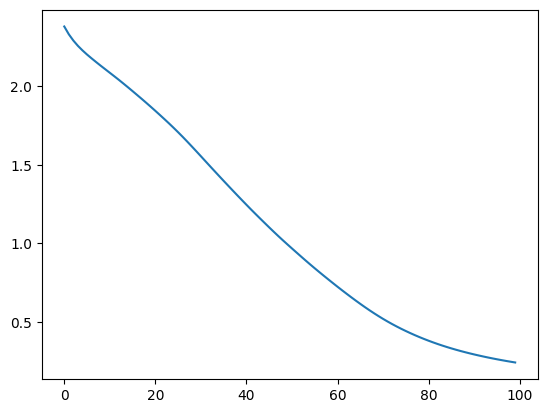

In [32]:
plt.plot(losses)

# 6-6. MultiLayer Perceptron으로 MNIST 분류하기

MNIST 데이터에 대한 설명 : https://wikidocs.net/60324

## 1. 데이터 로드하기

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml

In [35]:
mnist = fetch_openml('mnist_784', version = 1, cache = True, as_frame = False)

In [36]:
mnist.data[0]

array([  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,   0,   0,   3,  18,  18,  18,
       126, 136, 175,  26, 166, 255, 247, 127,   0,   0,   0,   0,   0,
         0,   0,   0,   0,   0,   0,   0,  30,  36,  94, 154, 17

In [37]:
mnist.target[0]

'5'

In [38]:
mnist.target = mnist.target.astype(np.int8)

모든 image data를 0 ~ 255 범위에서 0 ~ 1 범위로 정규화.

In [40]:
X = mnist.data / 255
y = mnist.target

In [44]:
X[54]

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.     

In [45]:
y[54]

np.int8(9)

이 이미지 데이터의 레이블은 9이다.


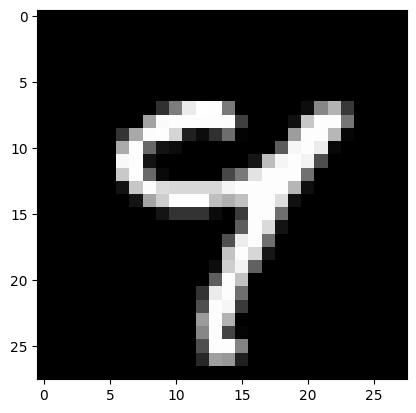

In [47]:
plt.imshow(X[54].reshape(28, 28), cmap = 'gray')
print("이 이미지 데이터의 레이블은 {:.0f}이다.".format(y[54]))

## 2. training data와 test data의 분리

In [48]:
import torch
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split

In [49]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 1/7, random_state = 0)

In [50]:
# 텐서로 변환
X_train = torch.Tensor(X_train)
X_test = torch.Tensor(X_test)
y_train = torch.LongTensor(y_train)
y_test = torch.LongTensor(y_test)

# TensorDataset 객체 생성
ds_train = TensorDataset(X_train, y_train)
ds_test = TensorDataset(X_test, y_test)

# DataLoader 객체 생성
loader_train = DataLoader(ds_train, batch_size=64, shuffle=True)
loader_test = DataLoader(ds_test, batch_size=64, shuffle=False)

## 3. MultiLayer Perceptron

In [58]:
from torch import nn
from torch import optim

In [59]:
model = nn.Sequential()
model.add_module('fc1', nn.Linear(28 * 28 * 1, 100))
model.add_module('relu1', nn.ReLU())
model.add_module('fc2', nn.Linear(100, 100))
model.add_module('relu2', nn.ReLU())
model.add_module('fc3', nn.Linear(100, 10))

In [60]:
print(model)

Sequential(
  (fc1): Linear(in_features=784, out_features=100, bias=True)
  (relu1): ReLU()
  (fc2): Linear(in_features=100, out_features=100, bias=True)
  (relu2): ReLU()
  (fc3): Linear(in_features=100, out_features=10, bias=True)
)


In [61]:
# loss function select
loss_fn = nn.CrossEntropyLoss()

# Weight를 학습하기 위한 optimization 기법 선택
optimizer = optim.Adam(model.parameters(), lr = 0.01)

In [62]:
# 총 10번의 에포크 동안 모델 학습
epochs = 10

for epoch in range(epochs):
  for data, targets in loader_train:
    optimizer.zero_grad()      # 옵티마이저의 기울기 초기화
    y_pred = model(data)          # 순전파 연산으로 예측값 계산
    loss = loss_fn(y_pred, targets)  # 손실 함수로 비용 계산
    loss.backward()            # 역전파 연산으로 기울기 계산
    optimizer.step()           # 옵티마이저를 통해 파라미터 업데이트

  print('Epoch {:4d}/{} Cost: {:.6f}'.format(epoch + 1, 10, loss.item()))

Epoch    1/10 Cost: 0.442360
Epoch    2/10 Cost: 0.233859
Epoch    3/10 Cost: 0.149096
Epoch    4/10 Cost: 0.010878
Epoch    5/10 Cost: 0.195608
Epoch    6/10 Cost: 0.419423
Epoch    7/10 Cost: 0.060175
Epoch    8/10 Cost: 0.040653
Epoch    9/10 Cost: 0.104145
Epoch   10/10 Cost: 0.100552


In [63]:
model.eval() # Neural Network를 추론 mode로 전환
correct = 0

# dataloader에서 mini batch를 하나씩 꺼내 추론 진행
with torch.no_grad():
  for data, targets in loader_test:

    outputs = model(data)

    _, predicted = torch.max(outputs.data, 1)
    correct += predicted.eq(targets.data.view_as(predicted)).sum()

data_num = len(loader_test.dataset)
print('\n테스트 데이터에서 예측 정확도: {}/{} ({:.0f}%)\n'.format(correct, data_num, 100. * correct / data_num))



테스트 데이터에서 예측 정확도: 9649/10000 (96%)



예측 결과 : 9
이 이미지 데이터의 정답 레이블은 9입니다


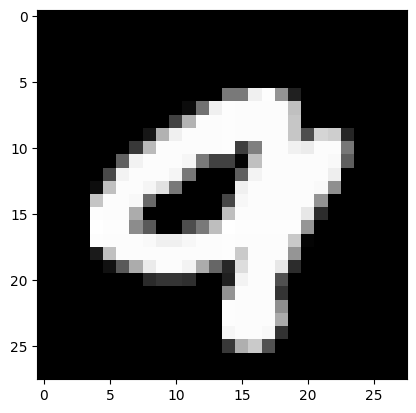

In [65]:
index = 2025

model.eval()  # 신경망을 추론 모드로 전환
data = X_test[index]
output = model(data)  # 데이터를 입력하고 출력을 계산
_, predicted = torch.max(output.data, 0)  # 확률이 가장 높은 레이블이 무엇인지 계산

print("예측 결과 : {}".format(predicted))

X_test_show = (X_test[index]).numpy()
plt.imshow(X_test_show.reshape(28, 28), cmap='gray')
print("이 이미지 데이터의 정답 레이블은 {:.0f}입니다".format(y_test[index]))

# 6-7. Overfitting을 막는 방법들

## 1. data의 양을 늘리기

## 2. model의 복잡도 줄이기

In [66]:
class Architecture1(nn.Module):
  def __init__(self, input_size, hidden_size, num_classes):
    super(Architecture1, self).__init__()
    self.fc1 = nn.Linear(input_size, hidden_size)
    self.relu = nn.ReLU()
    self.fc2 = nn.Linear(hidden_size, hidden_size)
    self.relu = nnReLU()
    self.fc3 = nn.Linear(hidden_size, num_classes)

  def forward(self, x):
    out = self.fc1(x)
    out = self.relu(out)
    out = self.fc2(out)
    out = self.relu(out)
    out = self.fc3(out)
    return out

위의 neural network가 overfitting 현상을 겪는다면 아래와 같이 복잡도를 줄이면 된다.

In [67]:
class Architecture1(nn.Module):
  def __init__(self, input_size, hidden_size, num_classes):
    super(Architecture1, self).__init__()
    self.fc1 = nn.Linear(input_size, hidden_size)
    self.relu = nn.ReLU()
    self.fc2 = nn.Linear(hidden_size, num_classes)

  def forward(self, x):
    out = self.fc1(x)
    out = self.relu(out)
    out = self.fc2(out)
    return out

Neural network에서 model에 있는 parameters의 수를 model의 **Capacity**라고 한다.

## 3. Regularization(가중치 규제) 진행하기

- L1 regularization: weight w들의 절댓값 합께를 cost function에 추가.
- L2 regularization: 모든 weight w들의 square sum을 cost function에 추가.

## 4. Dropout

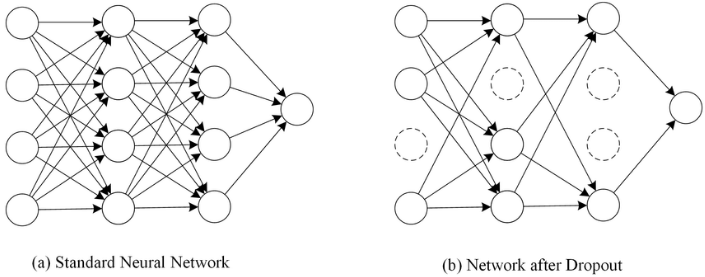

Dropout은 신경망 학습 시에만 사용하고, 예측 시에는 사용하지 않는 것이 일반적.

# 6-8. Gradient Vanishing and Exploding

Deep neural network를 학습하다 보면 back propagation 과정에서 input layer로 갈수록 gradient가 점차적으로 작아지는 현상이 발생할 수 있으며, 이를 **Gradient Vanishing**이라 한다. 반대로, 기울기가 점차 커지더니 weight가 발산하는 경우도 있으며, 이를 **Gradient Exploding**이라 한다.

## 1. ReLU와 ReLU의 변형들

- hidden layer에서는 sigmoid function을 사용하지 말 것.
- Leaky ReLU를 사용하면 모든 input에 대해 기울기가 0에 수렴하지 않기에 dying ReLU problem을 해결 가능
- hidden layer에서는 ReLU 또는 Leaky ReLU 등 ReLU의 변형을 사용할 것.

## 2. Weight initialization (가중치 초기화)